stage 1 : problem scoping 
          4 W's + 1H 
    1. who ? (stakeholeders)
        -primary stakeholders
          students whose  academic progress needs monitoring
          teachers who need to identify struggeling students
        - secondary stakeholders
          parents or guardians 
          college administrations
          academic counsellors 
        - end users of AI system 
          teachers
          academic support staff
    2. What ? [problem_statement]
        - tough to identify students who may perform poor in final exams 
        - current methods :
          manual monitoring 
          periodic test 
          techer Observations
        - define Problem :
        - there is a need for a data-driven system that predicts wheather a student is at
          risk of poor academic performance based on factos such as attendence , study habits , and previous resources 
    3. Where ? {context of the problem}
        - environment where students progress must be monitered 
          schools 
          colleges 
          coaching institutes 
          online platforms
    4.Why ?
        - Students :
          better learning resources / guidance 
          improved academic outcome
        -institutions :
         struggling students identification
         timely support 
         improve overall academic performance
         reduce failure and dropout rate
         enable data driven educational decisions 
    5. How ?
        steps :
        - collect student data(attendance , studyhours ,assingment )
        - analyze the patterns in the data 
        - train the model to classify students :
          at risk / not at risk 
        - provide predictions through a dashboard / app
        
         

In [68]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
np.random.seed(42)
n = 10000
data = pd.DataFrame({
    "student_id" : range(1 ,1+n),
    "study_hours" : np.random.normal(4 ,1.5 , n).clip(0 , 10),
    "attendance" :  np.random.normal(75 ,15 , n).clip(40 , 100),
    "previous_score" : np.random.normal(65 ,15 , n).clip(30 , 100),
    "assingment_created" : np.random.normal(0 ,10, n),
    "sleep_hours" : np.random.normal(7 ,1.2 , n).clip(4 , 10),
    "internet_access" : np.random.choice([0 ,1] , n ,p = [0.3 , 0.7]),
    "extra_curicular_activities" : np.random.choice([0,1] , n , p = [0.6 , 0.4]),
"Parental_control" : np.random.choice([0,1] , n , p = [0.4 , 0.6]),
})
data

,student_id,study_hours,attendance,previous_score,assingment_created,sleep_hours,internet_access,extra_curicular_activities,Parental_control
0,1,4.745071,64.822579,70.224294,-19.805720,6.433771,0,0,1
1,2,3.792604,70.417508,69.249854,-10.549856,8.215243,1,1,1
2,3,4.971533,66.039284,50.952202,-5.870284,6.762176,1,1,1
3,4,6.284545,76.656271,73.693763,1.496689,7.108683,1,0,1
4,5,3.648770,92.957678,42.648760,10.241623,7.860869,0,1,1
...,...,...,...,...,...,...,...,...,...
9995,9996,5.951653,80.817410,56.340682,11.196510,7.068159,1,0,0
9996,9997,1.002483,95.660499,86.669060,2.650340,6.970093,1,0,0
9997,9998,2.942025,80.675310,57.479490,6.165010,7.600102,1,0,1
9998,9999,4.743648,100.000000,36.614648,8.146235,7.318258,1,1,1


In [70]:
score = (
    data["study_hours"] * 5 +
           data["attendance"] * 0.3 +
           data["previous_score"] * 0.4 +
           data["assingment_created"] * 2 +
           data["Parental_control"] * 5 
)
          
data["final_result "] = np.where(score > 75 , "pass", "fail")

data.to_csv("student_performance.csv" , index= False)

data.head()

,student_id,study_hours,attendance,previous_score,assingment_created,sleep_hours,internet_access,extra_curicular_activities,Parental_control,final_result
0,1,4.745071,64.822579,70.224294,-19.805720,6.433771,0,0,1,fail
1,2,3.792604,70.417508,69.249854,-10.549856,8.215243,1,1,1,fail
2,3,4.971533,66.039284,50.952202,-5.870284,6.762176,1,1,1,fail
3,4,6.284545,76.656271,73.693763,1.496689,7.108683,1,0,1,pass
4,5,3.648770,92.957678,42.648760,10.241623,7.860869,0,1,1,pass


In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10000 non-null  int64  
 1   study_hours                 10000 non-null  float64
 2   attendance                  10000 non-null  float64
 3   previous_score              10000 non-null  float64
 4   assingment_created          10000 non-null  float64
 5   sleep_hours                 10000 non-null  float64
 6   internet_access             10000 non-null  int32  
 7   extra_curicular_activities  10000 non-null  int32  
 8   Parental_control            10000 non-null  int32  
 9   final_result                10000 non-null  object 
dtypes: float64(5), int32(3), int64(1), object(1)
memory usage: 664.2+ KB


In [72]:
data.describe()

,student_id,study_hours,attendance,previous_score,assingment_created,sleep_hours,internet_access,extra_curicular_activities,Parental_control
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,3.998833,74.955687,64.816000,-0.075715,7.008484,0.703800,0.400900,0.597800
std,2886.89568,1.499172,14.207260,14.652021,10.044871,1.188060,0.456603,0.490105,0.490366
min,1.00000,0.000000,40.000000,30.000000,-44.656039,4.000000,0.000000,0.000000,0.000000
25%,2500.75000,2.991114,65.069836,54.497721,-6.946129,6.203119,0.000000,0.000000,0.000000
50%,5000.50000,3.996108,75.237701,64.913476,-0.103822,7.011473,1.000000,0.000000,1.000000
75%,7500.25000,5.006621,85.407973,74.958461,6.790305,7.820602,1.000000,1.000000,1.000000
max,10000.00000,9.889357,100.000000,100.000000,37.278333,10.000000,1.000000,1.000000,1.000000


In [73]:
data.shape


(10000, 10)

In [74]:
data.value_counts()


student_id  study_hours  attendance  previous_score  assingment_created  sleep_hours  internet_access  extra_curicular_activities  Parental_control  final_result 
1           4.745071     64.822579   70.224294       -19.805720          6.433771     0                0                           1                 fail             1
6671        4.361315     49.701446   54.366339       -3.212377           8.399025     1                0                           1                 fail             1
6664        0.000000     90.582596   58.296225        7.711276           7.446943     1                0                           0                 fail             1
6665        2.920016     76.598170   46.510062        2.358581           7.834334     0                0                           1                 fail             1
6666        2.613906     84.524443   53.859222       -5.008129           7.411375     1                1                           0                 fail            

In [75]:
data["final_result "].value_counts()

final_result 
fail    5664
pass    4336
Name: count, dtype: int64

<Axes: xlabel='final_result ', ylabel='attendance'>

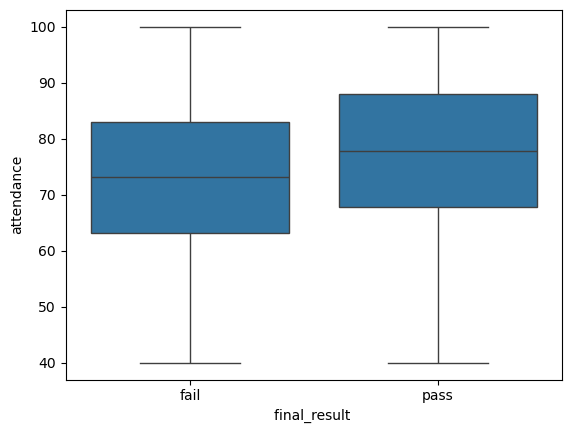

In [76]:
#boxplot to visualize the relationship between attendance and final result
sns.boxplot(x="final_result ", y="attendance", data=data)

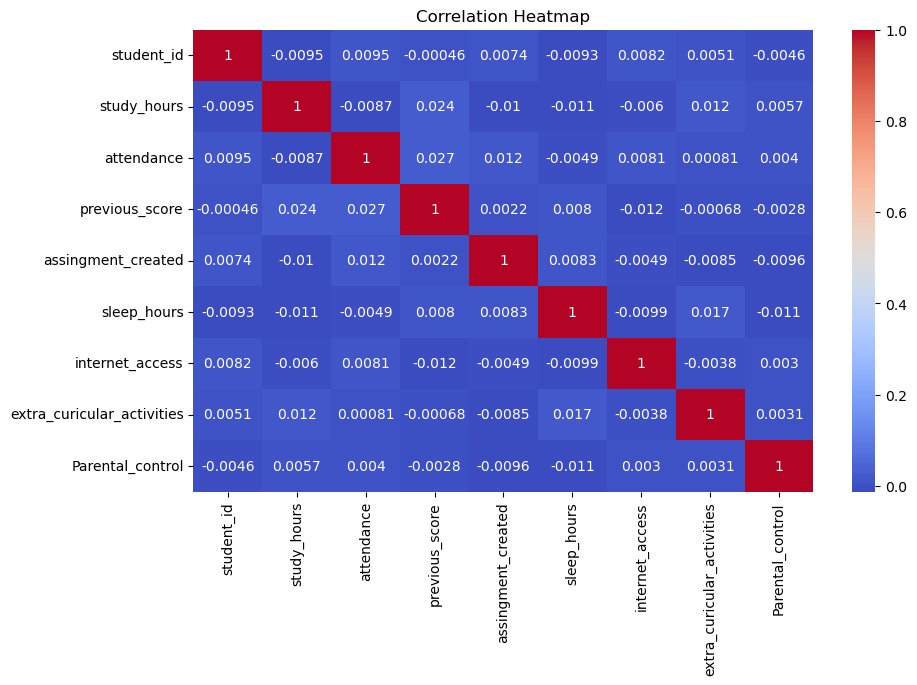

In [77]:
corr = data.corr(numeric_only = True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
